In [1]:
import os
from dotenv import load_dotenv
from pathlib import Path

#load_dotenv(Path(r"C:\Users\Jay.Sahu\langchain-academy\.env"))
load_dotenv()
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-academy"

In [10]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI()
llm.invoke("Hello LangSmith")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 10, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-D6hTKSvmgAdAAJBzFaKGF1j6onARA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c3964-fab4-77e2-80a6-aa306586c334-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 9, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph import MessagesState,StateGraph,START,END
from IPython.display import Image,display
from langchain_core.messages import HumanMessage

search_tool = TavilySearchResults(description = "Use this tool for answering current events, news or factual questions.")

tools = [search_tool]
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)


C:\Users\Jay.Sahu\AppData\Local\Temp\ipykernel_29952\2992221467.py:8: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(description = "Use this tool for answering current events, news or factual questions.")


In [3]:
def tool_calling_llm(state: MessagesState):
    return{
        "messages":[llm_with_tools.invoke(state["messages"])]
    }

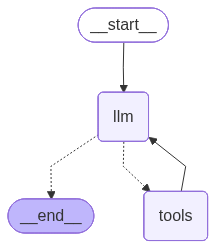

In [4]:
builder = StateGraph(MessagesState)
builder.add_node("llm",tool_calling_llm)
builder.add_node("tools",tool_node)
builder.add_edge(START,"llm")
builder.add_conditional_edges("llm",tools_condition)
builder.add_edge("tools","llm")
graph = builder.compile()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [5]:
result = graph.invoke({
        "messages":[HumanMessage(content="Latest AI news")]
})

In [11]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Latest AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_ZSkv9qCWjt8iAEHVwpVXa7js)
 Call ID: call_ZSkv9qCWjt8iAEHVwpVXa7js
  Args:
    query: latest AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business ...", "url": "https://www.artificialintelligence-news.com/", "content": "AI Business Strategy, Deep Dives, Featured News, Features, Governance, Regulation & Policy, Inside AI\n\n### Meeting the new ETSI standard for AI security\n\nAI Business Strategy, Deep Dives, Featured News\n\n### Why Apple chose Google over OpenAI: What enterprise AI buyers can learn from the Gemini deal\n\n## Latest\n\nAI and Us\n\nFebruary 5, 2026\n\n# AI Expo 2026 Day 2: Moving experimental pilots to AI prod

In [14]:
import gradio as gr
from langchain_core.messages import HumanMessage, AIMessage

def chat_with_agent(user_input, history):

    messages = []

    # Handle both tuple and dict history formats
    for item in history:

        # New Gradio format (dict)
        if isinstance(item, dict):
            if item["role"] == "user":
                messages.append(HumanMessage(content=item["content"]))
            else:
                messages.append(AIMessage(content=item["content"]))

        # Old Gradio format (tuple)
        else:
            human, ai = item
            messages.append(HumanMessage(content=human))
            messages.append(AIMessage(content=ai))

    # Add latest user message
    messages.append(HumanMessage(content=user_input))

    result = graph.invoke({"messages": messages})

    final_ai = next(
        m.content for m in reversed(result["messages"])
        if m.type == "ai" and m.content
    )

    history.append({"role": "user", "content": user_input})
    history.append({"role": "assistant", "content": final_ai})

    return "", history



with gr.Blocks() as demo:

    gr.Markdown("## 🔎 LangGraph Search Agent")

    chatbot = gr.Chatbot(height=200)
    msg = gr.Textbox(placeholder="Ask something...")

    msg.submit(chat_with_agent, [msg, chatbot], [msg, chatbot])

demo.launch()


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


NameError: name 'final_ai' is not defined